### Extract user comments from a web forum or blog post using web scraping. Perform sentiment analysis on the extracted data and identify the overall tone of the discussion. Visualize the sentiment distribution using a pie chart or bar graph.

No comments found. Using sample comments for demonstration.

--- Sentiment Analysis Results ---
                                       Comment Sentiment
           I love this post! Very informative.  Positive
This article is terrible and full of mistakes.  Negative
      Pretty good, but it needs more examples.  Positive
        I completely disagree with the author.  Positive
    Excellent explanation, thanks for sharing!  Positive

--- Sentiment Counts ---
Sentiment
Positive    4
Negative    1
Neutral     0
Name: count, dtype: int64


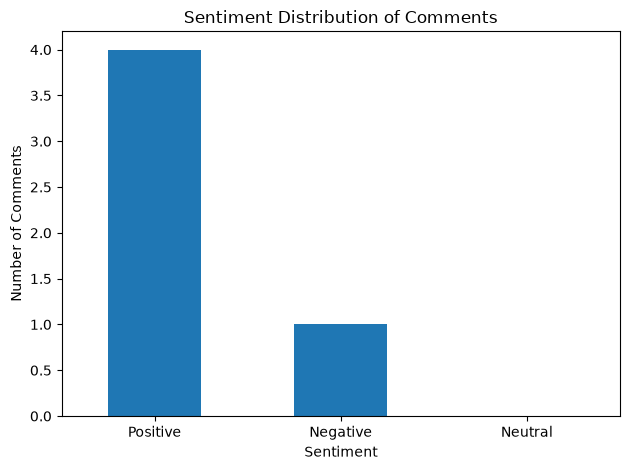

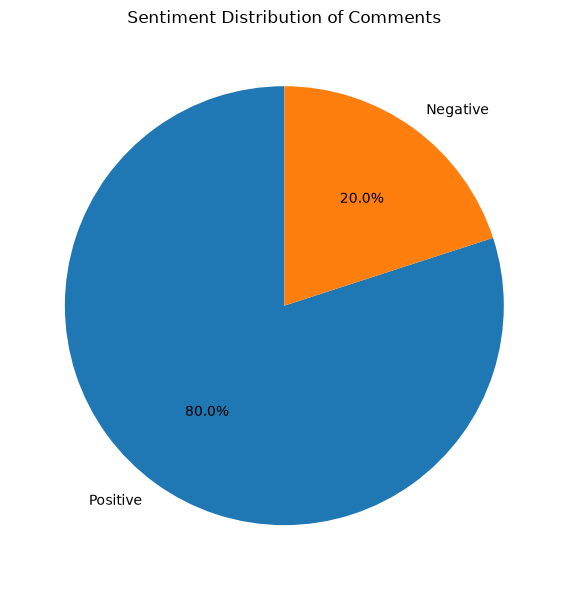

In [4]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from textblob import TextBlob

# 1. Enter a blog or forum URL
url = "https://www.sahyadri.edu.in/"

# 2. Scrape comments
def scrape_comments(url):
    response = requests.get(
        url,
        headers={"User-Agent": "Mozilla/5.0"},
        timeout=15
    )
    response.raise_for_status()
    soup = BeautifulSoup(response.text, "html.parser")

    # Change this selector to match the website's comment HTML
    comments_html = soup.select("p.comment-text")

    return [
        comment.get_text(" ", strip=True)
        for comment in comments_html
        if comment.get_text(strip=True)
    ]

try:
    comments = scrape_comments(url)
except requests.RequestException as e:
    print("Could not scrape the webpage:", e)
    comments = []

# 3. Sample comments if the website has no matching comments
# These demonstrate the program; they are NOT scraped comments.
if not comments:
    print("No comments found. Using sample comments for demonstration.")
    comments = [
        "I love this post! Very informative.",
        "This article is terrible and full of mistakes.",
        "Pretty good, but it needs more examples.",
        "I completely disagree with the author.",
        "Excellent explanation, thanks for sharing!"
    ]

# 4. Classify sentiment using TextBlob
def analyze_sentiment(comment):
    polarity = TextBlob(comment).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

sentiments = [analyze_sentiment(c) for c in comments]

# 5. Store results in a DataFrame
df = pd.DataFrame({
    "Comment": comments,
    "Sentiment": sentiments
})

print("\n--- Sentiment Analysis Results ---")
print(df.to_string(index=False))

# 6. Count sentiment categories
order = ["Positive", "Negative", "Neutral"]
sentiment_counts = (
    df["Sentiment"]
    .value_counts()
    .reindex(order, fill_value=0)
)

print("\n--- Sentiment Counts ---")
print(sentiment_counts)

# 7. Bar chart
sentiment_counts.plot(kind="bar", rot=0)
plt.title("Sentiment Distribution of Comments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.tight_layout()
plt.show()

# 8. Pie chart
nonzero_counts = sentiment_counts[sentiment_counts > 0]

plt.figure(figsize=(6, 6))
plt.pie(
    nonzero_counts.values,
    labels=nonzero_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Sentiment Distribution of Comments")
plt.tight_layout()
plt.show()